In [1]:
import numpy as np

# Create 3 complex numbers using numpy
z1 = 2 + 3j
z2 = -1 - 0.5j
z3 = 2.5 + 4j

In [2]:
from IPython.display import display, Math

def _complex_to_latex(z):
    """Convert a complex number to a readable LaTeX string."""
    z = complex(z)
    re, im = z.real, z.imag

    def fmt(x):
        if abs(x - round(x)) < 1e-12:
            return str(int(round(x)))
        return f"{x:g}"

    if abs(im) < 1e-12:
        return fmt(re)
    if abs(re) < 1e-12:
        if abs(im - 1) < 1e-12:
            return "i"
        if abs(im + 1) < 1e-12:
            return "-i"
        return f"{fmt(im)} i"

    sign = "+" if im >= 0 else "-"
    im_abs = abs(im)
    im_str = "i" if abs(im_abs - 1) < 1e-12 else f"{fmt(im_abs)} i"
    return f"{fmt(re)} {sign} {im_str}"


def display_large(expr):
    """Display a complex / numeric expression in LaTeX with large font size."""
    if isinstance(expr, (complex, np.complexfloating, float, int, np.floating, np.integer)):
        latex = _complex_to_latex(expr)
    else:
        latex = str(expr)
    display(Math(r"\large{%s}" % latex))


def display_huge(expr):
    """Display a complex / numeric expression in LaTeX with huge font size."""
    if isinstance(expr, (complex, np.complexfloating, float, int, np.floating, np.integer)):
        latex = _complex_to_latex(expr)
    else:
        latex = str(expr)
    display(Math(r"\huge{%s}" % latex))

In [3]:
display_large(z1)
display_large(z2)
display_large(z3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
print("z1 real part:", np.real(z1))
print("z1 imaginary part:", np.imag(z1))
print("=" * 20)

print("z2 real part:", np.real(z2))
print("z2 imaginary part:", np.imag(z2))
print("=" * 20)

print("z3 real part:", np.real(z3))
print("z3 imaginary part:", np.imag(z3))
print("=" * 20)

z1 real part: 2.0
z1 imaginary part: 3.0
z2 real part: -1.0
z2 imaginary part: -0.5
z3 real part: 2.5
z3 imaginary part: 4.0


In [5]:
# Represent each complex number as a 2D vector [Re(z), Im(z)]
vec_z1 = np.array([np.real(z1), np.imag(z1)])
vec_z2 = np.array([np.real(z2), np.imag(z2)])
vec_z3 = np.array([np.real(z3), np.imag(z3)])

print("vec_z1:", vec_z1)
print("vec_z2:", vec_z2)
print("vec_z3:", vec_z3)

vec_z1: [2. 3.]
vec_z2: [-1.  -0.5]
vec_z3: [2.5 4. ]


因為 $\arctan$ 有盲點，所以當我們要用 $\arctan$ 來計算 $\text{Arg}(z)$ 時，必須根據 $x$ 和 $y$ 所在的象限進行**分段修正**：

$$\text{Arg}(z) =  \begin{cases}  \arctan\left(\frac{y}{x}\right) & \text{if } x > 0 \quad (\text{第一、四象限}) \\ \arctan\left(\frac{y}{x}\right) + \pi & \text{if } x < 0, y \ge 0 \quad (\text{第二象限}) \\ \arctan\left(\frac{y}{x}\right) - \pi & \text{if } x < 0, y < 0 \quad (\text{第三象限}) \\ \frac{\pi}{2} & \text{if } x = 0, y > 0 \quad (\text{正 }y\text{ 軸}) \\ -\frac{\pi}{2} & \text{if } x = 0, y < 0 \quad (\text{負 }y\text{ 軸}) \\ \text{未定義} & \text{if } x = 0, y = 0 \quad (\text{原點}) \end{cases}$$

In [6]:
# Express z1 in Euler (polar) form: r*exp(i*theta)
# np.angle implements the quadrant-aware Arg(z) above (atan2)
r1, theta1 = np.abs(z1), np.angle(z1)
z1_euler = r1 * np.exp(1j * theta1)

print(f"r1 = {r1}, theta1 = {theta1}")
display_large(z1_euler)
print(f"Euler form: {r1} * exp(i * {theta1})")

r1 = 3.6055512754639896, theta1 = 0.982793723247329


<IPython.core.display.Math object>

Euler form: 3.6055512754639896 * exp(i * 0.982793723247329)


In [7]:
display_huge(z1_euler)
display(Math(rf"\huge{{{r1:.4g} \, e^{{i \,{theta1:.4g}}}}}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
display(z2)
r2, theta2 = np.abs(z2), np.angle(z2)
z2_euler = r2 * np.exp(1j * theta2)
display_huge(z2_euler)
display(Math(rf"\huge{{{r2:.4g} \, e^{{i \,{theta2:.4g}}}}}"))

(-1-0.5j)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
display(z3)
r3, theta3 = np.abs(z3), np.angle(z3)
z3_euler = r3 * np.exp(1j * theta3)
display_huge(z3_euler)
display(Math(rf"\huge{{{r3:.4g} \, e^{{i \,{theta3:.4g}}}}}"))

# Recover cartesian form from Euler form
z3_complex = z3_euler
display(z3_complex)

(2.5+4j)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

np.complex128(2.5+3.9999999999999996j)

In [10]:
z4 = 8

# Take the 6th roots of z4
# z^{1/n} = r^{1/n} * exp(i * (theta + 2*pi*k) / n), k = 0,...,n-1
n = 6
r4, theta4 = np.abs(z4), np.angle(z4)
roots_z4 = [
    r4 ** (1 / n) * np.exp(1j * (theta4 + 2 * np.pi * k) / n)
    for k in range(n)
]

for k, root in enumerate(roots_z4):
    rk, thetak = np.abs(root), np.angle(root)
    display(Math(
        rf"\huge{{z4_{{root_{k}}} = {rk:.4g}\, e^{{i\,{thetak:.4g}}}}}"
    ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
roots_z4_cartesian = [complex(root) for root in roots_z4]
for k, root_cart in enumerate(roots_z4_cartesian):
    display(Math(
        rf"\huge{{z4_{{root_{k}}} = {_complex_to_latex(root_cart)}}}"
    ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

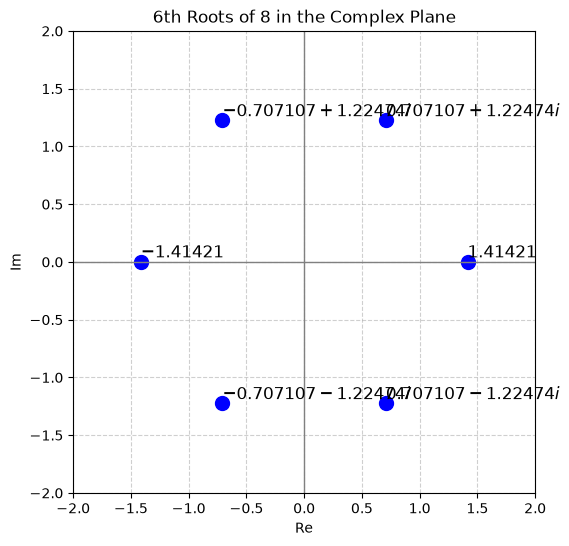

In [12]:
import matplotlib.pyplot as plt

# Prepare data for plotting
roots_x = [np.real(root) for root in roots_z4_cartesian]
roots_y = [np.imag(root) for root in roots_z4_cartesian]

plt.figure(figsize=(6, 6))
plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)
plt.scatter(roots_x, roots_y, color="blue", s=100)

for i, (x, y) in enumerate(zip(roots_x, roots_y)):
    label = _complex_to_latex(roots_z4_cartesian[i])
    plt.text(x, y, f"${label}$", fontsize=12, ha="left", va="bottom")

plt.title("6th Roots of 8 in the Complex Plane")
plt.xlabel("Re")
plt.ylabel("Im")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()